In [1]:
import pandas as pd
import bnlearn

import pooch

import causalpype as cp
import networkx as nx

[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


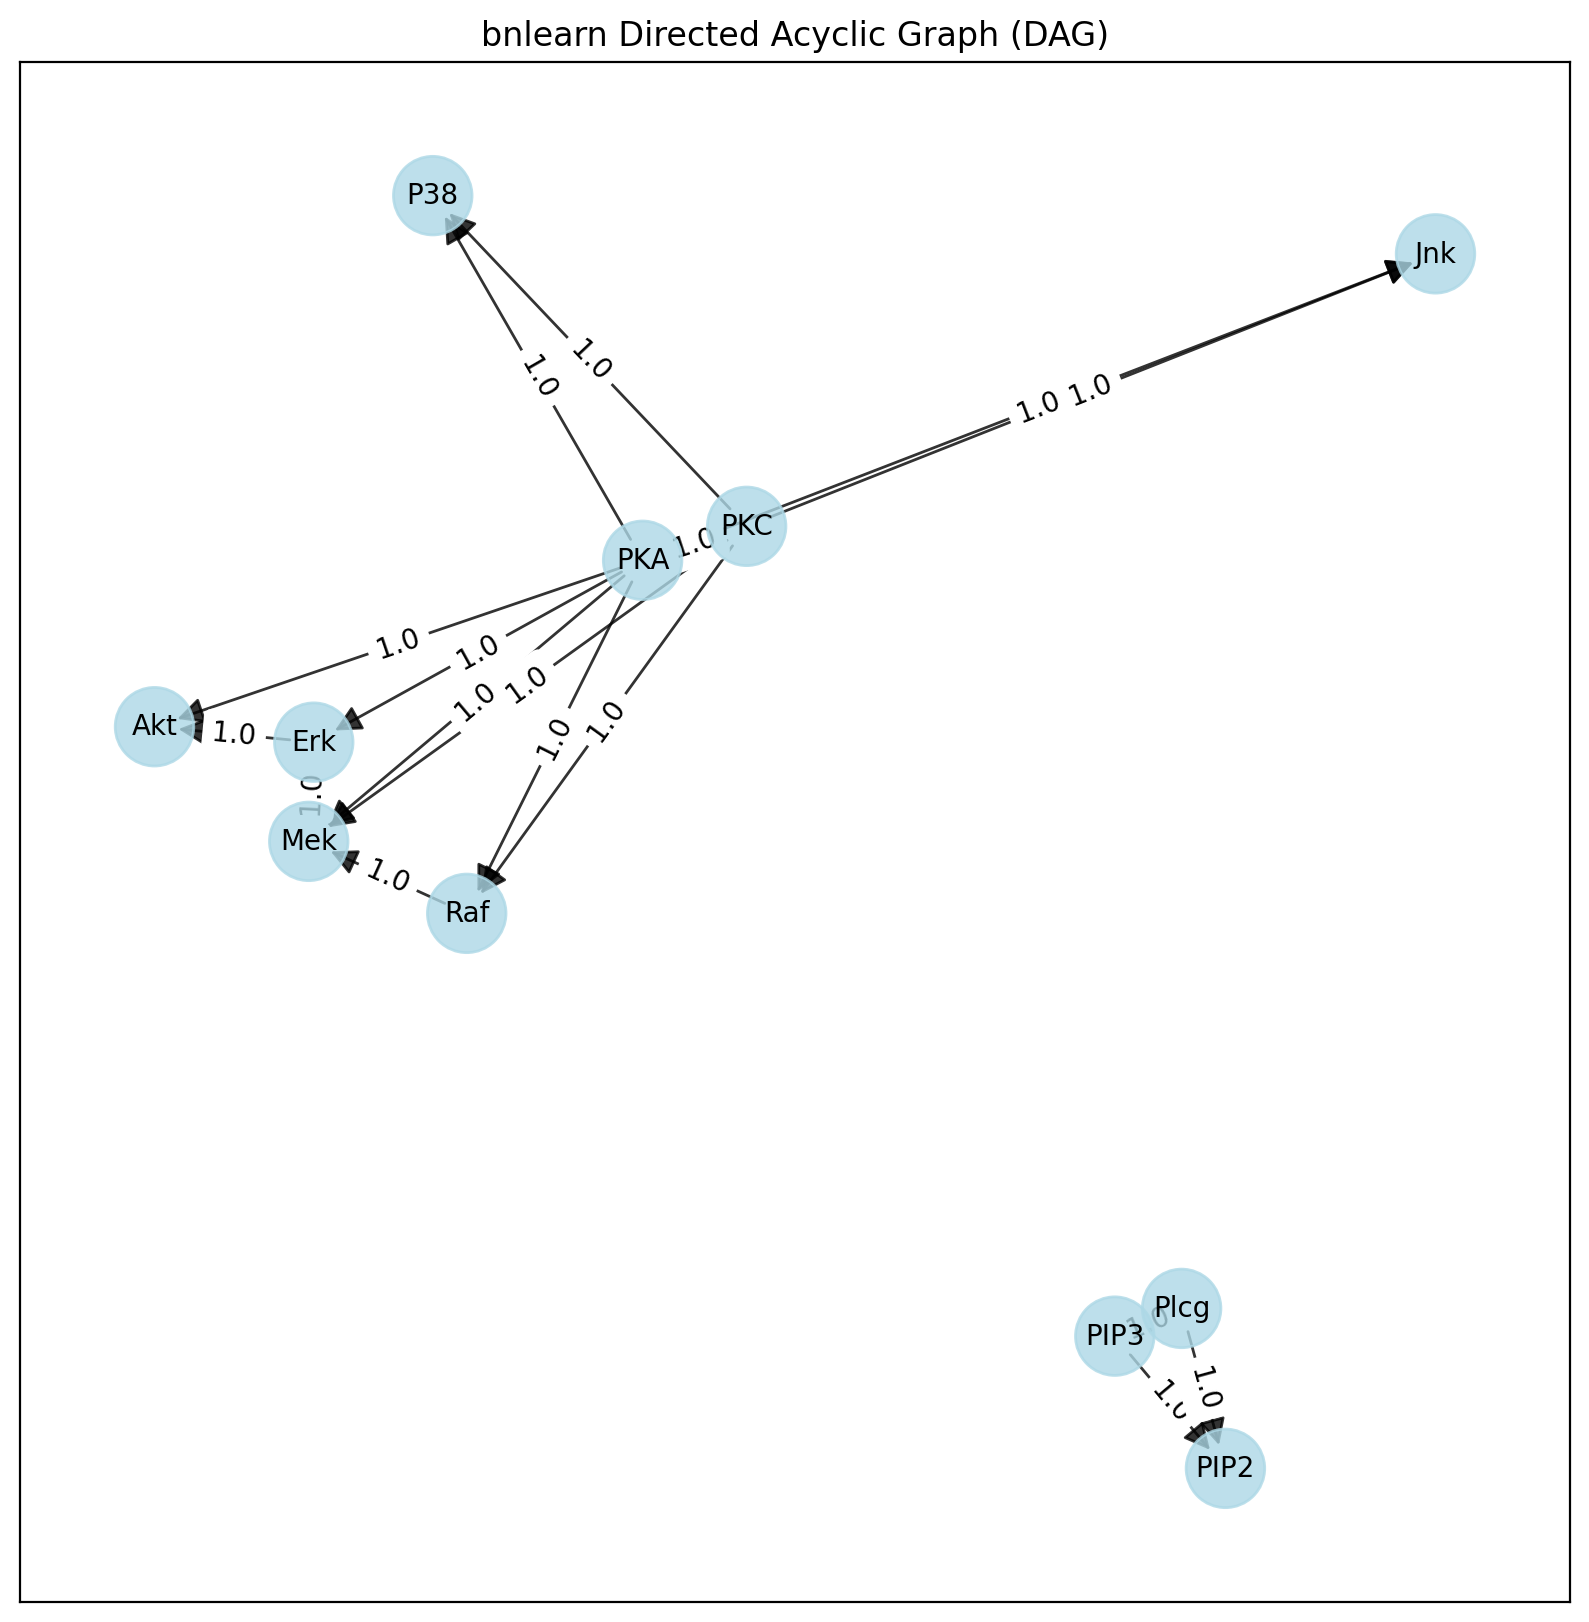

   Raf  Mek  Plcg  PIP2  PIP3  Erk  Akt  PKA  PKC  P38  Jnk  INT
0    1    1     1     2     3    2    1    3    1    2    1    8
1    1    1     1     1     3    3    2    3    1    2    1    8
2    1    1     2     2     3    2    1    3    2    1    1    8
3    1    1     1     1     3    2    1    3    1    3    1    8
4    1    1     1     1     3    2    1    3    1    1    1    8
(5400, 12)


In [2]:
# use pooch to download robustly from a url
url = "https://www.bnlearn.com/book-crc/code/sachs.interventional.txt.gz"
file_path = pooch.retrieve(
    url=url,
    known_hash="md5:39ee257f7eeb94cb60e6177cf80c9544",
)

df = pd.read_csv(file_path, delimiter=" ")

# the ground-truth dag is shown here: XXX: comment in when errors are fixed
ground_truth_dag = bnlearn.import_DAG("sachs", verbose=False)
fig = bnlearn.plot(ground_truth_dag)

# .. note::
#    The Sachs dataset has previously been preprocessed, and the steps are described
#    in bnlearn, at the web-page https://www.bnlearn.com/research/sachs05/.
print(df.head())
print(df.shape)

In [3]:
df.head()

,Raf,Mek,Plcg,PIP2,PIP3,Erk,Akt,PKA,PKC,P38,Jnk,INT
0,1,1,1,2,3,2,1,3,1,2,1,8
1,1,1,1,1,3,3,2,3,1,2,1,8
2,1,1,2,2,3,2,1,3,2,1,1,8
3,1,1,1,1,3,2,1,3,1,3,1,8
4,1,1,1,1,3,2,1,3,1,1,1,8


In [4]:
df.columns

Index(['Raf', 'Mek', 'Plcg', 'PIP2', 'PIP3', 'Erk', 'Akt', 'PKA', 'PKC', 'P38',
       'Jnk', 'INT'],
      dtype='object')

In [5]:
df.describe()

,Raf,Mek,Plcg,PIP2,PIP3,Erk,Akt,PKA,PKC,P38,Jnk,INT
count,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000
mean,1.693889,1.533704,1.292222,1.212963,2.116852,2.121481,1.470741,1.915556,1.672037,1.378519,1.538333,4.333333
std,0.789236,0.689920,0.644821,0.523409,0.748062,0.615643,0.639992,0.544635,0.640976,0.685400,0.635737,3.742004
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,4.000000
75%,2.000000,2.000000,1.000000,1.000000,3.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,8.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,9.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Raf     5400 non-null   int64
 1   Mek     5400 non-null   int64
 2   Plcg    5400 non-null   int64
 3   PIP2    5400 non-null   int64
 4   PIP3    5400 non-null   int64
 5   Erk     5400 non-null   int64
 6   Akt     5400 non-null   int64
 7   PKA     5400 non-null   int64
 8   PKC     5400 non-null   int64
 9   P38     5400 non-null   int64
 10  Jnk     5400 non-null   int64
 11  INT     5400 non-null   int64
dtypes: int64(12)
memory usage: 506.4 KB


In [7]:
ground_truth_dag

{'model': <pgmpy.models.BayesianNetwork.BayesianNetwork at 0x169c553d0>,
 'adjmat': target    Erk    Akt    PKA    Mek    Jnk    PKC    Raf    P38   PIP3   PIP2  \
 source                                                                         
 Erk     False   True  False  False  False  False  False  False  False  False   
 Akt     False  False  False  False  False  False  False  False  False  False   
 PKA      True   True  False   True   True  False   True   True  False  False   
 Mek      True  False  False  False  False  False  False  False  False  False   
 Jnk     False  False  False  False  False  False  False  False  False  False   
 PKC     False  False   True   True   True  False   True   True  False  False   
 Raf     False  False  False   True  False  False  False  False  False  False   
 P38     False  False  False  False  False  False  False  False  False  False   
 PIP3    False  False  False  False  False  False  False  False  False   True   
 PIP2    False  False  Fal

In [8]:
adjmat = ground_truth_dag['adjmat']

In [9]:
adjmat

target,Erk,Akt,PKA,Mek,Jnk,PKC,Raf,P38,PIP3,PIP2,Plcg
source,,,,,,,,,,,
Erk,False,True,False,False,False,False,False,False,False,False,False
Akt,False,False,False,False,False,False,False,False,False,False,False
PKA,True,True,False,True,True,False,True,True,False,False,False
Mek,True,False,False,False,False,False,False,False,False,False,False
Jnk,False,False,False,False,False,False,False,False,False,False,False
PKC,False,False,True,True,True,False,True,True,False,False,False
Raf,False,False,False,True,False,False,False,False,False,False,False
P38,False,False,False,False,False,False,False,False,False,False,False
PIP3,False,False,False,False,False,False,False,False,False,True,False


In [10]:
print(adjmat.columns.tolist())
print(adjmat.index.tolist())


['Erk', 'Akt', 'PKA', 'Mek', 'Jnk', 'PKC', 'Raf', 'P38', 'PIP3', 'PIP2', 'Plcg']
['Erk', 'Akt', 'PKA', 'Mek', 'Jnk', 'PKC', 'Raf', 'P38', 'PIP3', 'PIP2', 'Plcg']


In [ ]:
G = nx.from_pandas_adjacency(adjmat.astype('int'), create_using=nx.DiGraph)
G

In [12]:
model = cp.CausalModel(G, assignment_quality='good')

In [13]:
model

CausalModel(not fitted, nodes=['Erk', 'Akt', 'PKA', 'Mek', 'Jnk', 'PKC', 'Raf', 'P38', 'PIP3', 'PIP2', 'Plcg'], edges=[('Erk', 'Akt'), ('PKA', 'Erk'), ('PKA', 'Akt'), ('PKA', 'Mek'), ('PKA', 'Jnk'), ('PKA', 'Raf'), ('PKA', 'P38'), ('Mek', 'Erk'), ('PKC', 'PKA'), ('PKC', 'Mek'), ('PKC', 'Jnk'), ('PKC', 'Raf'), ('PKC', 'P38'), ('Raf', 'Mek'), ('PIP3', 'PIP2'), ('Plcg', 'PIP3'), ('Plcg', 'PIP2')])

CausalModel(fitted, nodes=['Erk', 'Akt', 'PKA', 'Mek', 'Jnk', 'PKC', 'Raf', 'P38', 'PIP3', 'PIP2', 'Plcg'], edges=[('Erk', 'Akt'), ('PKA', 'Erk'), ('PKA', 'Akt'), ('PKA', 'Mek'), ('PKA', 'Jnk'), ('PKA', 'Raf'), ('PKA', 'P38'), ('Mek', 'Erk'), ('PKC', 'PKA'), ('PKC', 'Mek'), ('PKC', 'Jnk'), ('PKC', 'Raf'), ('PKC', 'P38'), ('Raf', 'Mek'), ('PIP3', 'PIP2'), ('Plcg', 'PIP3'), ('Plcg', 'PIP2')])

(<Figure size 1400x1000 with 1 Axes>, <Axes: title={'center': 'Causal Graph'}>)

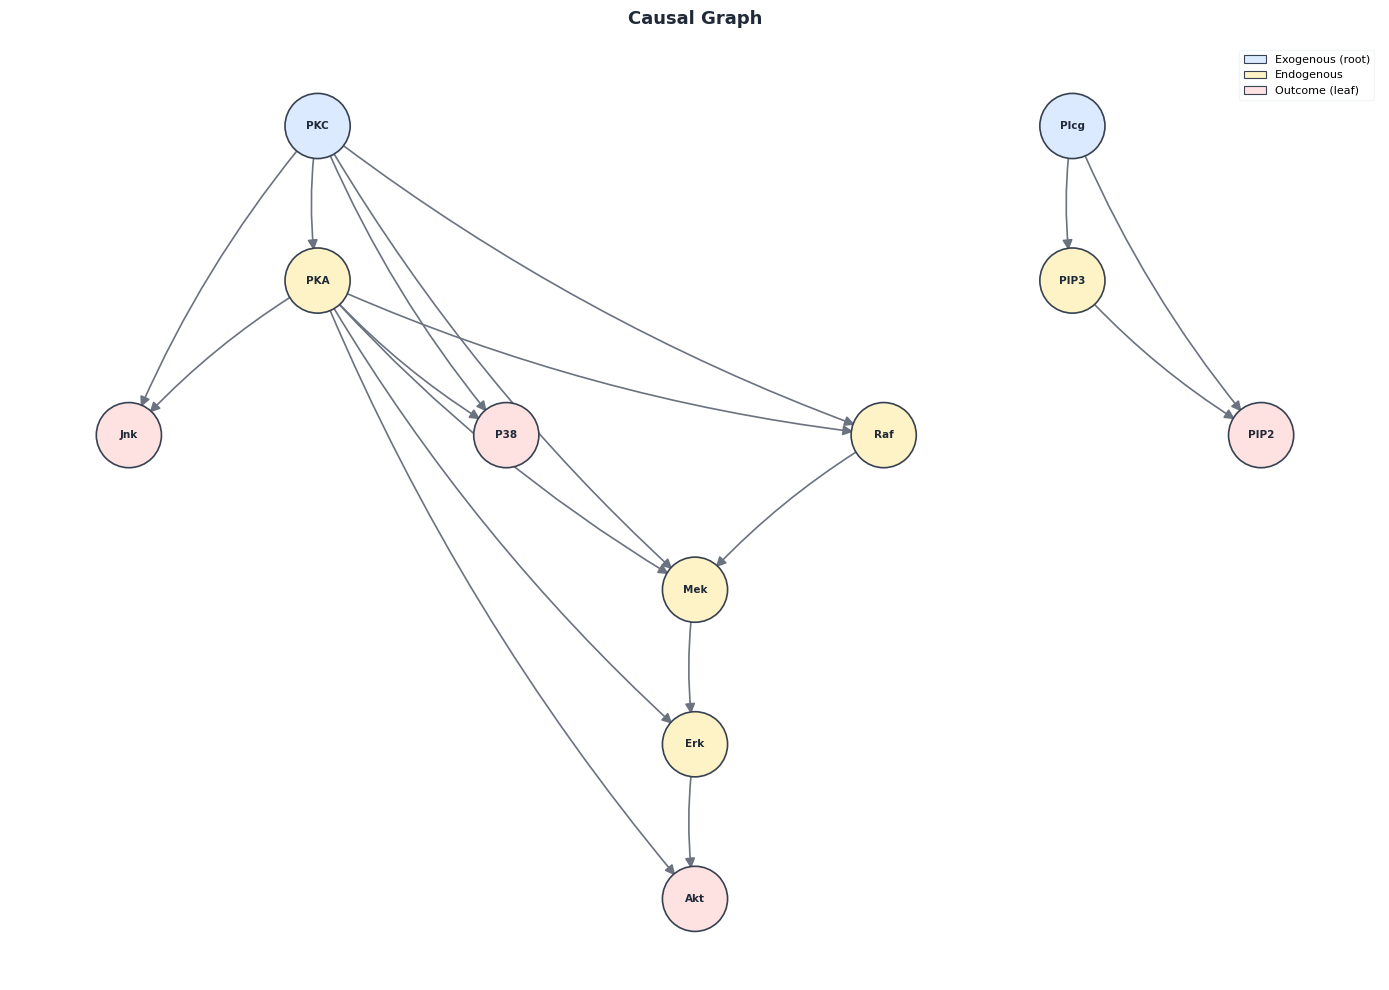

In [14]:
cp.plotting.plot_graph(model)

In [15]:
model.fit(df)

Fitting causal mechanism of node Plcg: 100%|██████████| 11/11 [00:08<00:00,  1.28it/s]


CausalModel(fitted, nodes=['Erk', 'Akt', 'PKA', 'Mek', 'Jnk', 'PKC', 'Raf', 'P38', 'PIP3', 'PIP2', 'Plcg'], edges=[('Erk', 'Akt'), ('PKA', 'Erk'), ('PKA', 'Akt'), ('PKA', 'Mek'), ('PKA', 'Jnk'), ('PKA', 'Raf'), ('PKA', 'P38'), ('Mek', 'Erk'), ('PKC', 'PKA'), ('PKC', 'Mek'), ('PKC', 'Jnk'), ('PKC', 'Raf'), ('PKC', 'P38'), ('Raf', 'Mek'), ('PIP3', 'PIP2'), ('Plcg', 'PIP3'), ('Plcg', 'PIP2')])

In [16]:
val = model.run(cp.Validate(method='all'))

In [17]:
val.summary()

                    Validation Results                    
 Result                                       ISSUES FOUND
----------------------------------------------------------
 Structure Validation
    Passed                                              No
    N Tests                                             26
    Bonferroni Level                                0.0019
----------------------------------------------------------
 Model Validation
    Passed                                              No
    Result                                        REJECTED


In [18]:
arrow_strength = model.run(cp.ArrowStrength(target="Akt"))
arrow_strength.summary()


                  Arrow Strength Results                  
 Target                                                Akt
----------------------------------------------------------
  Erk -> Akt                                        0.1613
  PKA -> Akt                                        0.1551


In [19]:
result = model.run(cp.ATE(treatment="PKA", outcome="Akt", treatment_value=3, control_value=1))
result.summary()

                       ATE Results                        
 Treatment                                             PKA
 Outcome                                               Akt
 Treatment Value                                         3
 Control Value                                           1
----------------------------------------------------------
 Estimate                                          -0.7220
 Num Samples                                         2,000


In [20]:
result = model.run(cp.CausalEffectCurve(treatment="PKA", outcome="Akt"))
result.summary()

               Causal Effect Curve Results                
 Treatment                                             PKA
 Outcome                                               Akt
----------------------------------------------------------
 do(PKA)               E[Akt]        Std
----------------------------------------------------------
 1.0000                2.0110     0.8677
 1.1053                2.0310     0.8307
 1.2105                1.9750     0.8487
 1.3158                1.8780     0.8894
 1.4211                1.8600     0.8476
                  ...                 
 2.5789                1.2570     0.5735
 2.6842                1.2700     0.5737
 2.7895                1.2680     0.5479
 2.8947                1.2610     0.5890
 3.0000                1.3000     0.6083


(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Causal Effect Curve: PKA → Akt'}, xlabel='do(PKA)', ylabel='E[Akt]'>)

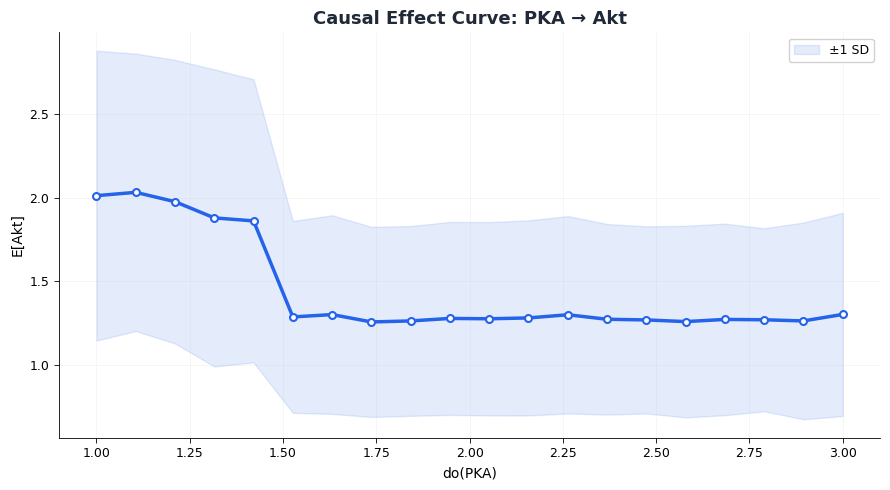

In [21]:
cp.plotting.plot_causal_effect_curve(result)

In [22]:
result = model.run(cp.IntrinsicCausalInfluence(target="Akt"))
result.summary()

Evaluating set functions...: 100%|██████████| 54/54 [00:14<00:00,  3.83it/s]


            Intrinsic Causal Influence Results            
 Target                                                Akt
 Total Variance Explained                           0.4907
----------------------------------------------------------
  Akt (39.0%)                                       0.1913
  Erk (29.6%)                                       0.1451
  PKA (21.9%)                                       0.1076
  Mek (4.1%)                                        0.0202
  PKC (3.2%)                                        0.0155
  Raf (2.2%)                                        0.0108


(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Intrinsic Causal Influence on ‘Akt’'}, xlabel='Proportion of Variance Explained'>)

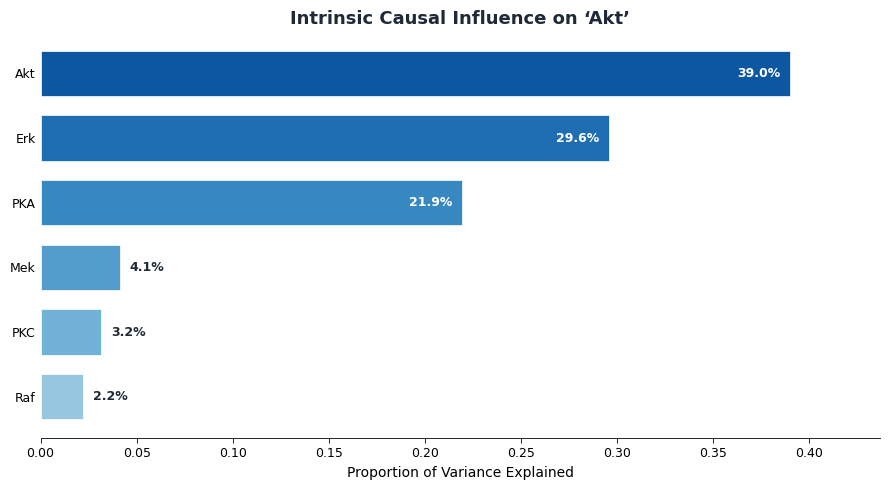

In [23]:
cp.plotting.plot_influences(result)

In [24]:
result = model.run(cp.SensitivityAnalysis(treatment="PKA", outcome="Akt", treatment_value=3, control_value=1))
result.summary()

Fitting causal mechanism of node _random_cause: 100%|██████████| 12/12 [00:09<00:00,  1.23it/s]


               Sensitivity Analysis Results               
 Result                                             ROBUST
 Original ATE                                      -0.7545
----------------------------------------------------------
 Placebo
    Mean Effect                                    -0.0006
    Std Effect                                      0.0169
    P-value                                         0.0000
    Passed                                             Yes
----------------------------------------------------------
 Subset
    Mean Effect                                    -0.7573
    Std Effect                                      0.0239
    Fraction                                        0.8000
    Passed                                             Yes
----------------------------------------------------------
 Random Common Cause
    Mean Effect                                    -0.7278
    Std Effect                                      0.0220
    Passed        

In [29]:
result = model.run(cp.Intervention(
    interventions={"Plcg": 3},
    outcome="Erk",
))
result.summary()


ValueError: X has 1 features, but HistGradientBoostingRegressor is expecting 2 features as input.

In [ ]:
for node in model.graph.nodes:
    parents = list(model.graph.predecessors(node))
    if len(parents) > 0:
        try:
            parent_data = model.data[parents].values[:5]
            cm = model.scm.causal_mechanism(node)
            cm.draw_samples(parent_data)
            print(f"{node}: OK ({len(parents)} parents: {parents})")
        except Exception as e:
            print(f"{node}: FAILED ({len(parents)} parents: {parents}) — {e}")
    else:
        print(f"{node}: root node")


Erk: OK (2 parents: ['PKA', 'Mek'])
Akt: FAILED (2 parents: ['Erk', 'PKA']) — X has 2 features, but HistGradientBoostingRegressor is expecting 3 features as input.
PKA: FAILED (1 parents: ['PKC']) — X has 1 features, but HistGradientBoostingRegressor is expecting 2 features as input.
Mek: OK (3 parents: ['PKA', 'PKC', 'Raf'])
Jnk: OK (2 parents: ['PKA', 'PKC'])
PKC: root node
Raf: OK (2 parents: ['PKA', 'PKC'])
P38: OK (2 parents: ['PKA', 'PKC'])
PIP3: OK (1 parents: ['Plcg'])
PIP2: OK (2 parents: ['PIP3', 'Plcg'])
Plcg: root node


In [30]:
# Build a clean DiGraph without edge attributes
G2 = nx.DiGraph()
adjmat = ground_truth_dag['adjmat']
for src in adjmat.index:
    for tgt in adjmat.columns:
        if adjmat.loc[src, tgt]:
            G2.add_edge(src, tgt)

# Refit
model2 = cp.CausalModel(G2)
model2.fit(model.data)

# Verify mechanisms
for node in model2.graph.nodes:
    parents = list(model2.graph.predecessors(node))
    if parents:
        try:
            parent_data = model.data[parents].values[:5]
            cm = model2.scm.causal_mechanism(node)
            cm.draw_samples(parent_data)
            print(f"{node}: OK ({len(parents)} parents)")
        except Exception as e:
            print(f"{node}: FAILED — {e}")
    else:
        print(f"{node}: root")


Fitting causal mechanism of node Plcg: 100%|██████████| 11/11 [00:02<00:00,  5.42it/s]

Erk: OK (2 parents)
Akt: OK (2 parents)
PKA: OK (1 parents)
Mek: OK (3 parents)
Jnk: OK (2 parents)
Raf: OK (2 parents)
P38: OK (2 parents)
PKC: root
PIP3: OK (1 parents)
PIP2: OK (2 parents)
Plcg: root


In [31]:
result = model2.run(cp.KNNIntervention(
    treatment="PKC",
    outcome="Erk",
    treatment_value=3,
    control_value=1,
    k=5,
))
result.summary()


                 KNN Intervention Results                 
 Treatment                                             PKC
 Outcome                                               Erk
 K                                                       5
 N Treated                                             514
 N Control                                           2,285
----------------------------------------------------------
 ATE                                                0.2119
 ATT                                                0.1401
 ATC                                                0.2281
 Std ITE                                            0.6513
----------------------------------------------------------
 Match Quality (Treated)                            1.6104
 Match Quality (Control)                            3.0860


In [32]:
# Quick check — did model2 fix the broken mechanisms?
for node in ["Akt", "PKA"]:
    parents = list(model2.graph.predecessors(node))
    try:
        cm = model2.scm.causal_mechanism(node)
        cm.draw_samples(model2.data[parents].values[:5])
        print(f"{node}: OK")
    except Exception as e:
        print(f"{node}: FAILED — {e}")


Akt: OK
PKA: OK


In [33]:
cm = model2.scm.causal_mechanism("PKA")
print(f"Type: {type(cm)}")
print(f"Prediction model: {type(cm.prediction_model)}")
if hasattr(cm.prediction_model, 'sklearn_model'):
    print(f"Expected features: {cm.prediction_model.sklearn_model.n_features_in_}")
print(f"Actual parents: {list(model2.graph.predecessors('PKA'))}")


Type: <class 'dowhy.gcm.causal_mechanisms.DiscreteAdditiveNoiseModel'>
Prediction model: <class 'dowhy.gcm.ml.regression.SklearnRegressionModel'>
Expected features: 1
Actual parents: ['PKC']


In [34]:
result = model2.run(cp.Counterfactual(
    interventions={"PKC": 3},
    outcome="Erk",
))
result.summary()


                  Counterfactual Results                  
 Interventions                                    PKC := 3
 N Units                                             5,400
 Outcome                                               Erk
----------------------------------------------------------
 Factual Mean                                       2.1215
 Counterfactual Mean                                2.0294
 Mean Effect                                       -0.0920


In [35]:
cf_high = model2.run(cp.Counterfactual(interventions={"PKC": 3}, outcome="Erk"))
cf_low = model2.run(cp.Counterfactual(interventions={"PKC": 1}, outcome="Erk"))

print(f"E[Erk | do(PKC=3)]: {cf_high.details['counterfactual_mean']:.4f}")
print(f"E[Erk | do(PKC=1)]: {cf_low.details['counterfactual_mean']:.4f}")
print(f"Contrast:           {cf_high.details['counterfactual_mean'] - cf_low.details['counterfactual_mean']:.4f}")


E[Erk | do(PKC=3)]: 2.0294
E[Erk | do(PKC=1)]: 2.1415
Contrast:           -0.1120


In [36]:
result = model2.run(cp.Intervention(
    interventions={"PKC": 3},
    outcome="Erk",
    num_samples=5000,
))
result.summary()


                   Intervention Results                   
 Interventions                                    PKC := 3
 Outcome                                               Erk
----------------------------------------------------------
 Mean                                               1.9876
 Std                                                0.6624


In [37]:
result = model2.run(cp.CATE(
    treatment="PKC",
    outcome="Erk",
    effect_modifiers=["Raf", "Mek"],
    method="causal_forest",
))
result.summary()


                       CATE Results                       
 Treatment                                             PKC
 Outcome                                               Erk
 Effect Modifiers                                 Raf, Mek
 Method                                      causal_forest
----------------------------------------------------------
 Mean Effect                                        0.0378
 Std Effect                                         0.2473
 Bounds                                  [-0.6274, 0.3586]


In [38]:
result = model2.run(cp.CATE(
    treatment="PKC",
    outcome="Erk",
    effect_modifiers=["Raf", "Mek"],
    method="metalearner",
))
result.summary()


ValueError: Found unknown categories [np.int64(0)] in column 0 during transform